In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Amazon Sale Report.csv", low_memory=False)
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
df.shape

(128975, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [ ]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [ ]:
df.drop("Unnamed: 22", axis=1, inplace=True)

In [ ]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='object')

In [ ]:
df.drop("index", axis=1, inplace=True)

In [ ]:
df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [ ]:
df.drop("fulfilled-by", axis=1, inplace=True)

In [ ]:
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [ ]:
df.drop("promotion-ids", axis=1, inplace=True)

In [ ]:
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [ ]:
df["Amount"] = df["Amount"].fillna(df["Amount"].mean())

In [ ]:
df["Amount"].isnull().sum()

np.int64(0)

In [ ]:
df["currency"].mode()

,currency
0,INR


In [ ]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [ ]:
df.drop(["index","promotion-ids","fulfilled-by","Unnamed: 22"], axis=1, inplace=True)

In [ ]:
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [ ]:
df["currency"] = df["currency"].fillna("INR")

In [ ]:
df["ship-city"] = df["ship-city"].fillna("Unknown")
df["ship-state"] = df["ship-state"].fillna("Unknown")
df["ship-country"] = df["ship-country"].fillna("Unknown")
df["ship-postal-code"] = df["ship-postal-code"].fillna(0)

In [ ]:
df["Courier Status"] = df["Courier Status"].fillna("Unknown")

In [ ]:
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [ ]:
df.groupby("Category")["Amount"].sum()

,Amount
Category,
Blouse,4.875934e+05
Bottom,1.636392e+05
Dupatta,9.150000e+02
Ethnic Dress,8.340227e+05
Saree,1.297708e+05
Set,4.130676e+07
Top,5.644185e+06
Western Dress,1.173233e+07
kurta,2.334900e+07


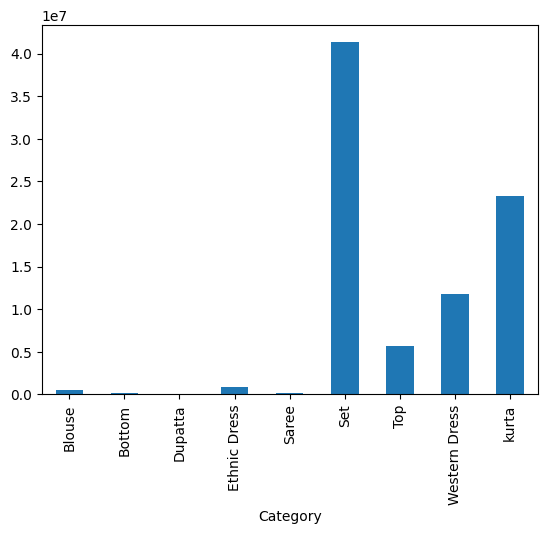

In [ ]:
import matplotlib.pyplot as plt

df.groupby("Category")["Amount"].sum().plot(kind="bar")

plt.show()

In [ ]:
df.groupby("Status")["Amount"].sum()

,Amount
Status,
Cancelled,1.182630e+07
Pending,4.315681e+05
Pending - Waiting for Pick Up,1.921380e+05
Shipped,5.045916e+07
Shipped - Damaged,1.136000e+03
Shipped - Delivered to Buyer,1.865600e+07
Shipped - Lost in Transit,1.997000e+03
Shipped - Out for Delivery,2.697100e+04
Shipped - Picked Up,6.612520e+05


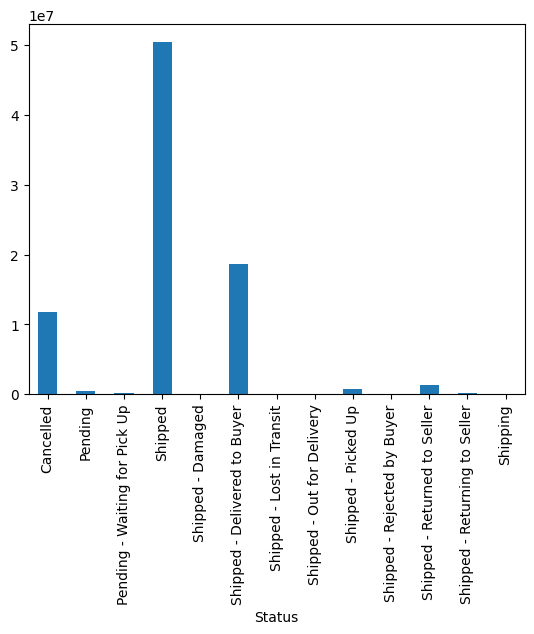

In [ ]:
import matplotlib.pyplot as plt

df.groupby("Status")["Amount"].sum().plot(kind="bar")

plt.xticks(rotation=90)
plt.show()

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], format="%m-%d-%y", errors="coerce")

In [ ]:
df["Date"].head()

,Date
0,2022-04-30
1,2022-04-30
2,2022-04-30
3,2022-04-30
4,2022-04-30


In [ ]:
df["Month"] = df["Date"].dt.month

In [ ]:
df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,Month
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,Unknown,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,4
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,4
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,4
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,Unknown,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,4
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,4


In [ ]:
df.groupby("Month")["Amount"].sum()

,Amount
Month,
3,1.075209e+05
4,3.078374e+07
5,2.785047e+07
6,2.490648e+07


In [ ]:
df.groupby("ship-state")["Amount"].sum()

,Amount
ship-state,
ANDAMAN & NICOBAR,1.678035e+05
ANDHRA PRADESH,3.463042e+06
APO,6.485615e+02
AR,4.930000e+02
ARUNACHAL PRADESH,9.977493e+04
...,...
goa,2.467000e+03
orissa,5.970000e+02
punjab,9.270561e+03


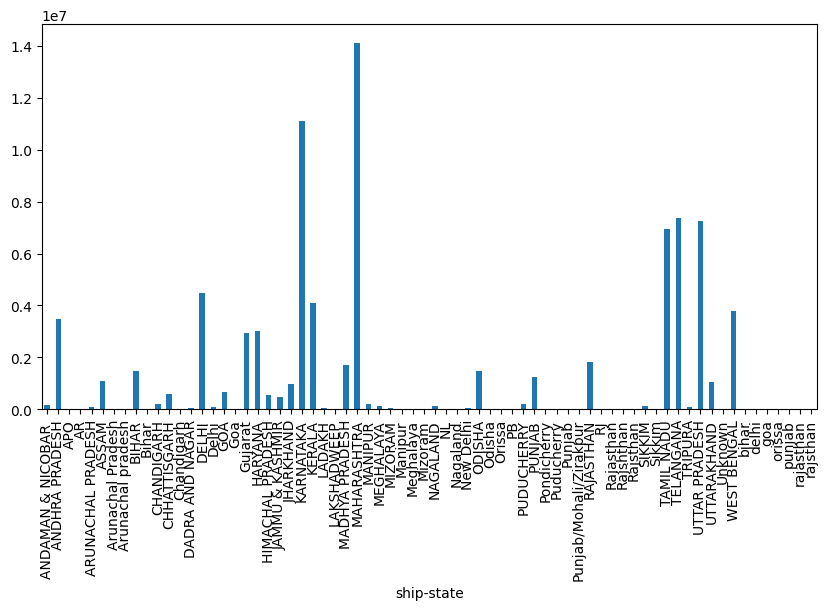

In [ ]:
df.groupby("ship-state")["Amount"].sum().plot(kind="bar", figsize=(10,5))

plt.show()

In [ ]:
df.to_csv("cleaned_ecommerce.csv", index=False)

In [ ]:
import os
os.listdir()

['.config', 'Amazon Sale Report.csv', 'cleaned_ecommerce.csv', 'sample_data']